This notebook fits by-cre models on the shendure data & demonstrates that estimated nb parameters track closely with UMI means, as expected.

The matrix-creation and fitting code is independent of the main scMPRA package, since its this analysis that informed the package code.

In [3]:
#imports
import pandas as pd
import numpy as np
import time
import pickle

from formulaic import Formula

import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import linregress

from tensorzinb.tensorzinb import TensorZINB

import scMPRAforge as scm


In [4]:
%load_ext autoreload
%autoreload 2

In [5]:
data_root="/gpfs/gibbs/pi/reilly/tabula_data"
shendure=scm.scMPRA_data.from_tsv(f"{data_root}/shendure/shendure_counts_grouped.txt")

In [6]:
shendure.set_negative_controls(["minP","noP"])

In [7]:
shendure.ortho_filter()

In [8]:
def tensorzinb_fit(matricies):
    """
    Takes matricies as returned by `create_matricies` & produces a tensorzinb model
    """
    zinbo = TensorZINB(endog=matricies["regressand"]["umis_mpra_bc"].to_numpy().reshape((-1, 1)),
                       exog=matricies["nb_regressors"].to_numpy(),
                       exog_infl=matricies["zi_regressors"].to_numpy(),)
                       #exog_c=matricies["shared_regressors"],
                       #exog_infl_c=matricies["shared_regressors"])  # ,same_dispersion=True
    zinb_result = None
    try:
        zinb_result = zinbo.fit(init_method="nb")
    except pd.errors.InvalidIndexError:
        return "index_error"

    return zinb_result

def create_matricies(nb_formula,zi_formula,scmpra):
    """
    Takes a scMPRA_data object & formulas & produces design matricies. 
    """
    data=scmpra
    y, X=Formula(nb_formula).get_model_matrix(data,output='pandas')
    Z=Formula(zi_formula).get_model_matrix(data,output='pandas')
    return {
        'nb_regressors':X,
        'regressand':y,
        'zi_regressors':Z
    }

In [9]:
first_time=True
QC={}


if first_time:
    
    #loop through all cell-types, produce 
    for cre_id in shendure.data["cre_id"].unique():
        print(cre_id)

        ##subset to current cell-type##
        shendure_subset=shendure.data[shendure.data["cre_id"]==cre_id]


        ## create design matricies ##
        matricies=create_matricies(nb_formula="umis_mpra_bc ~ C(cell_type)",
                            zi_formula="C(rep_id)-1",
                            scmpra=shendure_subset)
        
        ## take the mean for comparison##
        shendure_mean=shendure_subset.groupby("cell_type")["umis_mpra_bc"].agg("mean").sort_values()

        ## fit a model##
        model=tensorzinb_fit(matricies)

        if model=="index_error":
            print("index error")
            continue

        ## compute predictions of mu from the model ##
        linear_mu=matricies["nb_regressors"].to_numpy() @ model["weights"]["x_mu"]
        mu_predictions=np.exp(linear_mu)

        #compute predictions of ZI from the model
        #linear_zi=(matricies["zi_regressors"].to_numpy() @ model["weights"]["x_pi"])
        #zi_predictions=linear_zi=1/(1+np.exp(-linear_zi))

        ## get the names of the cell-types ##
        cell_labeling=scm.undo_one_hot_encoding(matricies["nb_regressors"])["cell_type"]
        cell_labeling=cell_labeling.str.removeprefix("T.")

        ## label the predictions with CRE names ##
        mu_predictions_df=pd.DataFrame({'cell_type':cell_labeling,'mu':mu_predictions.squeeze()})
        mu_predictions_df.sort_values(by='mu')

        ## merge means & predicted mu into one df for convienient plotting ##
        mu_summary=mu_predictions_df.groupby("cell_type").agg("mean")
        mu_summary = mu_summary.merge(shendure_mean.rename_axis('cell_type').reset_index(), on='cell_type', how='left')
        
        ### Regress & store data for plotting ###
        
        x = mu_summary["umis_mpra_bc"]
        y = mu_summary["mu"]

        # Fit regression
        slope, intercept, r_value, p_value, std_err = linregress(x, y)

        #store regression info
        ret={'x':x,
            'y':y,
            'model':model,
            'slope':slope,
            'intercept':intercept,
            'r_value':r_value,
            'p_value':p_value,
            'std_err':std_err
        }
        
        QC[cre_id]=ret
    with open(f"{data_root}/shendure/cache_cre.pkl","wb") as f:
        pickle.dump(QC,f)
else:
    #not first time
    with open(f"{data_root}/shendure/cache_cre.pkl","rb") as f:
        QC=pickle.load(f)

Gata4_chr14_5710
Metal device set to: Apple M4 Pro

systemMemory: 24.00 GB
maxCacheSize: 8.00 GB

Klf4_chr4_3952
Lama1_chr17_7793
Sox17_chr1_67
Sox17_chr1_82
Sparc_chr11_7203
Sparc_chr11_7235
negative_control
Bend5_chr4_8170
Bend5_chr4_8199
Bend5_chr4_8201
Btg1_chr10_9572
Btg1_chr10_9588
Col5a1_chr2_2558
Col5a1_chr2_2565
Col5a1_chr2_2576
Epas1_chr17_10056
Epas1_chr17_10066
Epas1_chr17_10071
Foxa2_chr2_13808
Foxa2_chr2_13841
Foxa2_chr2_13861
Gata4_chr14_5749
Gata4_chr14_5752
Gata4_chr14_5763
Gata4_chr14_5776
Igfbp4_chr11_16740
Igfbp4_chr11_16743
Klf4_chr4_3946
Klf4_chr4_3951
Lama1_chr17_7814
Lamb1_chr12_2183
Lamb1_chr12_2216
Lamb1_chr12_2239
Lamc1_chr1_12152
Map1b_chr13_9429
Map1b_chr13_9447
Sox17_chr1_69
Sox2_chr3_2009
Sox4_chr13_2054
Sox4_chr13_2057
Sparc_chr11_7199
Sparc_chr11_7213
Sparc_chr11_7233
Sparc_chr11_7243
Tgfbi_chr13_5705
Tubb2b_chr13_2577
Tubb2b_chr13_2580
Tubb2b_chr13_2590
Txndc12_chr4_7951
Txndc12_chr4_7975
Txndc12_chr4_7978
eef1aP
pgk1P
ubcP
Bend5_chr4_8174
Cited2_chr10

KeyError: 'cell_type'

Let's examine the min & max estimates for each cell-type to make sure they are in the right ballpark.

In [ ]:
for cell_type in QC:
    dat=QC[cell_type]["y"]
    print(f"{cell_type} : {min(dat)} to {max(dat)}")

NeuroectodermBrain : 0.0039693062143633644 to 192.82009660133235
EpiblastPrimitiveStreak : 0.010311376539302619 to 448.5050036969967
SurfaceEctoderm : 0.005302743658352733 to 113.54948913739214
Mesoderm : 0.004091263766921424 to 131.04886871206176
Pluripotent : 0.005810704105665507 to 360.6842751814721
Haematoendothelial : 0.0181892393174459 to 266.6863899534262
Cardiomyocytes : 0.02600122899385187 to 185.30029229848444
NeuroectodermRostral : 0.010501271679121684 to 55.52375204700398
ExEndodermParietal : 0.005629854700954823 to 48.84290712493864
ExEndodermVisceral : 0.0084486417521796 to 218.1020939433304


All in the right ballpark!

Let's examine the correlations between data mean & estimated mu parameters...

In [ ]:
for cell_type in QC:
    print(f"{cell_type} : r={QC[cell_type]['r_value']}, slope={QC[cell_type]['slope']}")

NeuroectodermBrain : r=0.9999954242947022, slope=1.0190224517966084
EpiblastPrimitiveStreak : r=0.9999895797420258, slope=1.0192153123657208
SurfaceEctoderm : r=0.9999956917835242, slope=1.013843862953523
Mesoderm : r=0.9999944784808024, slope=1.014760843113512
Pluripotent : r=0.9999997736981998, slope=1.0030526794841392
Haematoendothelial : r=0.9999482641565658, slope=1.0389246274603385
Cardiomyocytes : r=0.999938427544322, slope=1.0390477745275455
NeuroectodermRostral : r=0.9998713564987006, slope=1.0032270147540308
ExEndodermParietal : r=0.9999911978229975, slope=1.00684203172837
ExEndodermVisceral : r=0.9999968679455745, slope=1.0078008673625072


Correlations look very good. Let's check for outliers:

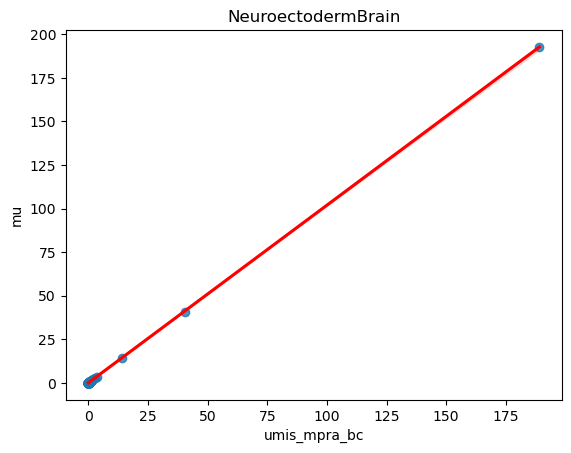

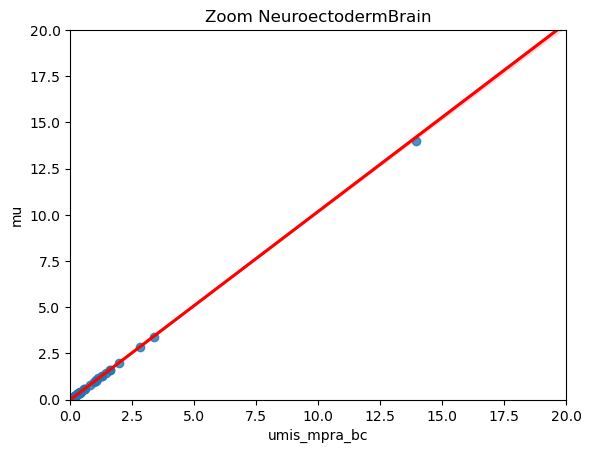

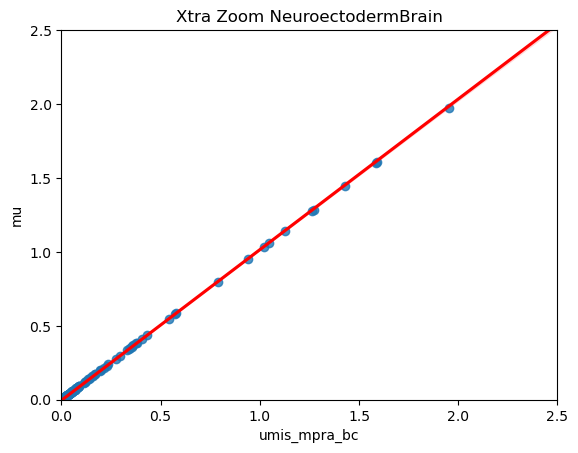

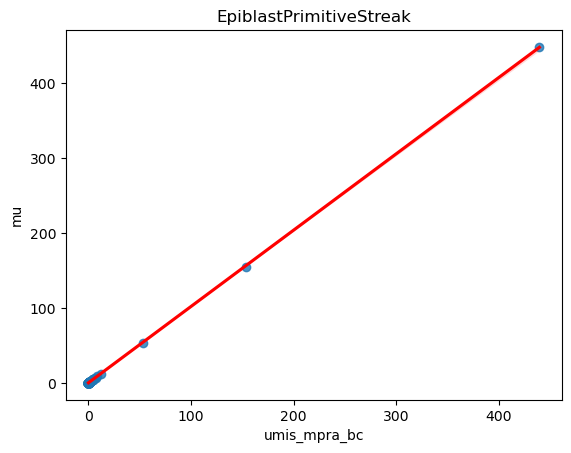

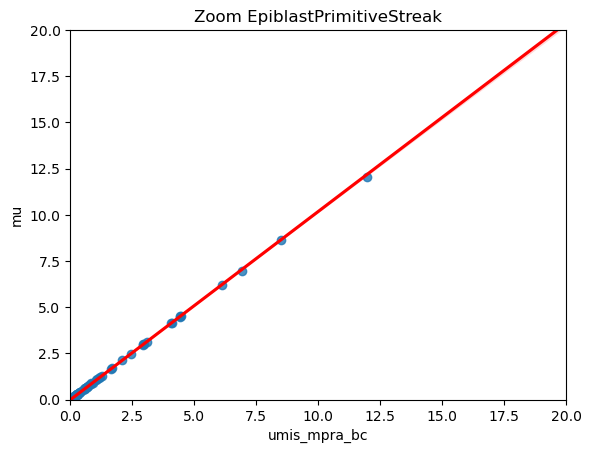

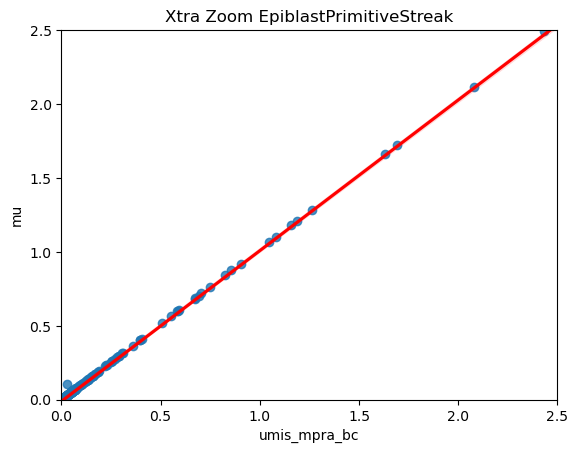

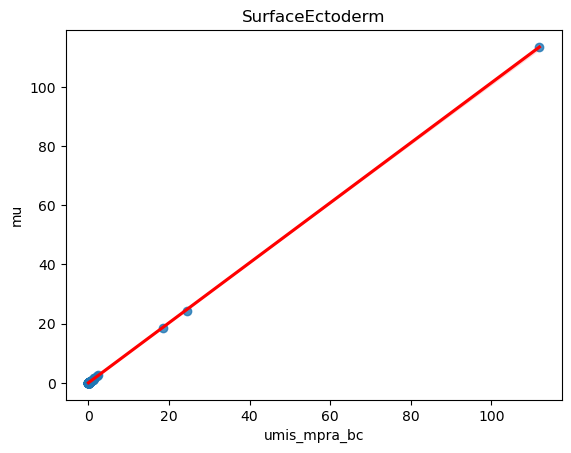

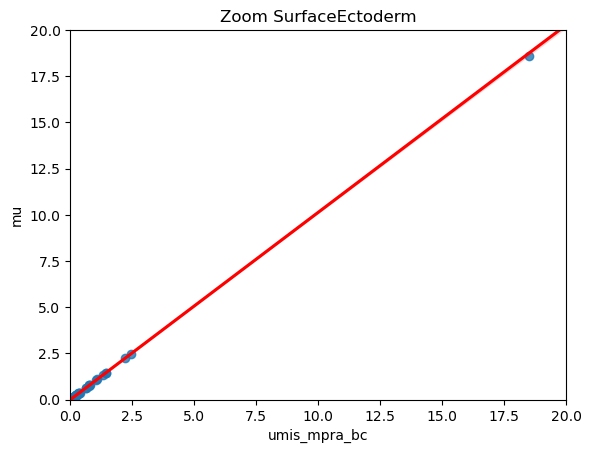

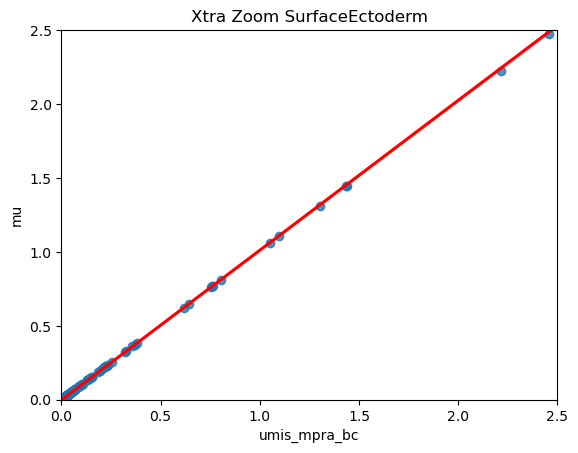

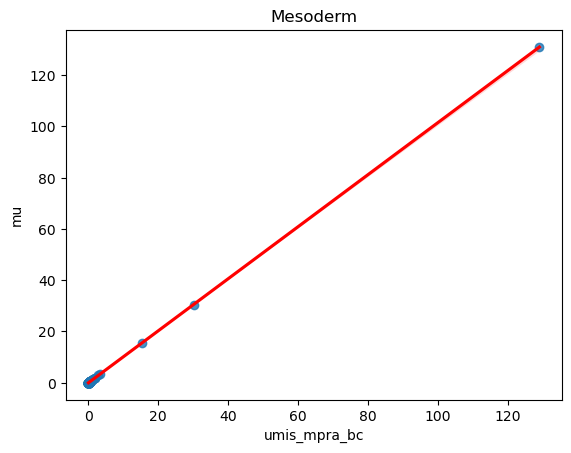

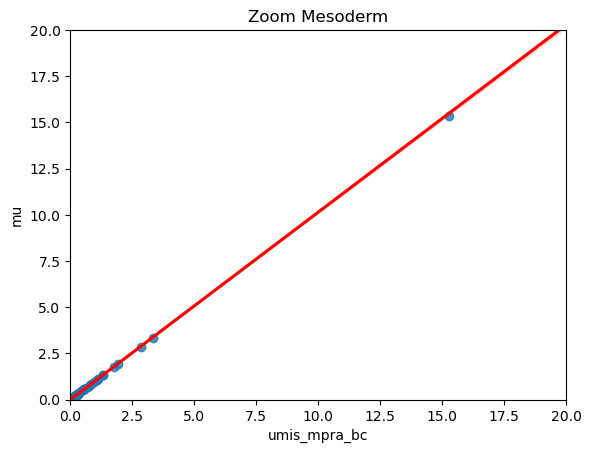

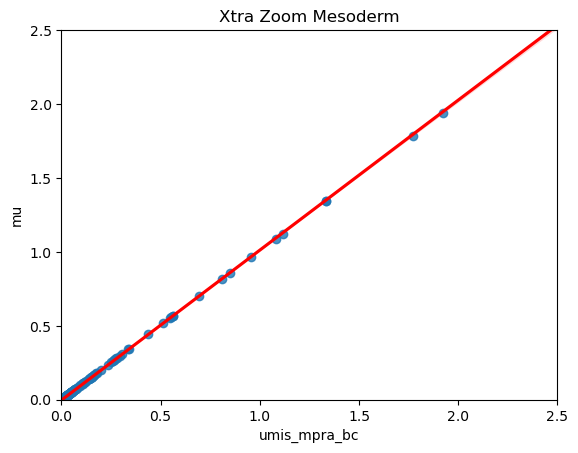

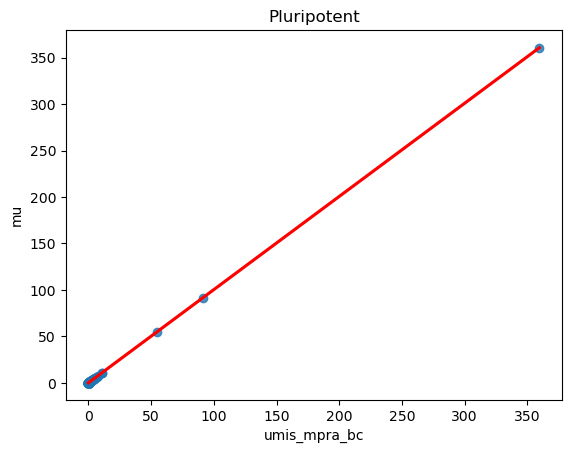

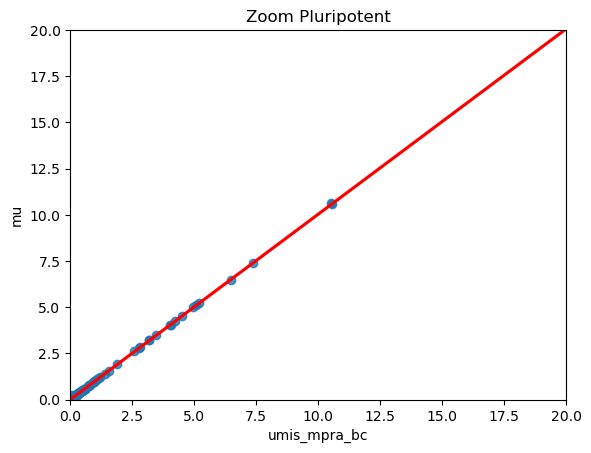

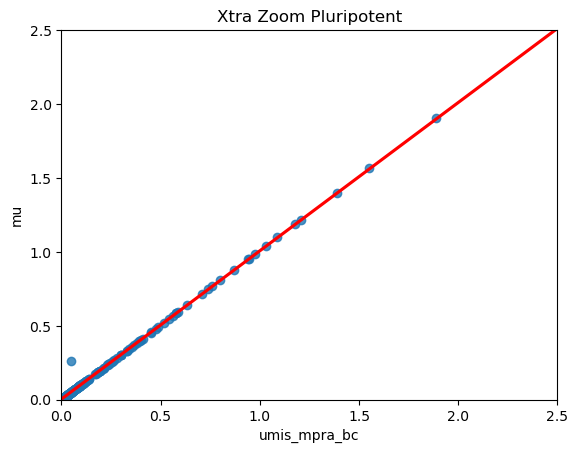

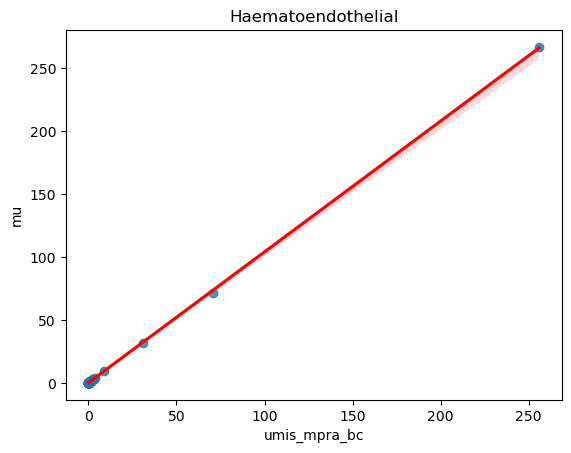

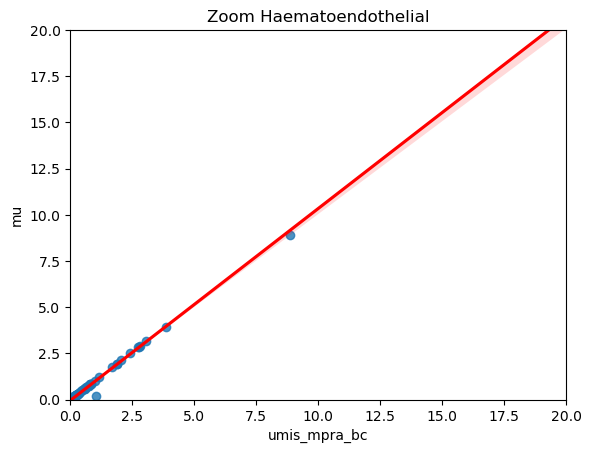

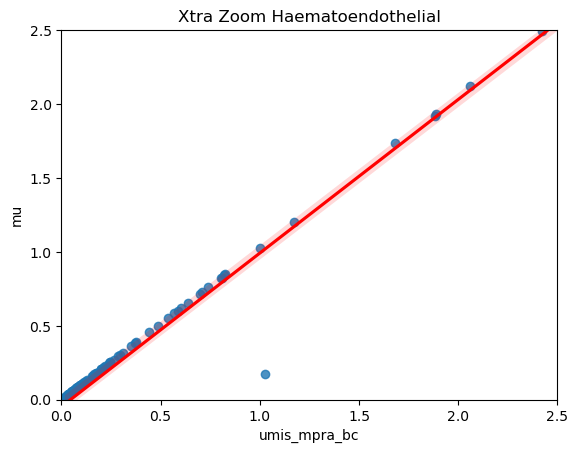

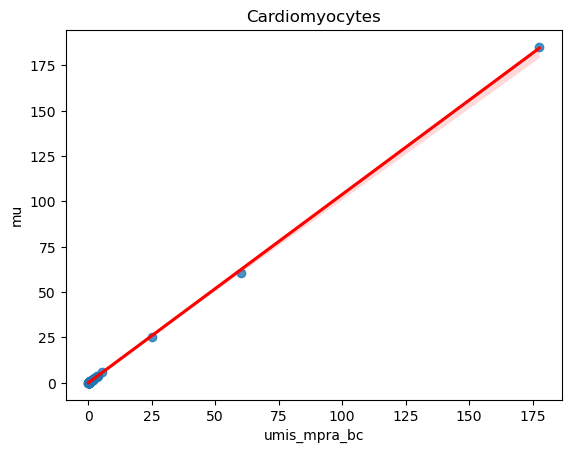

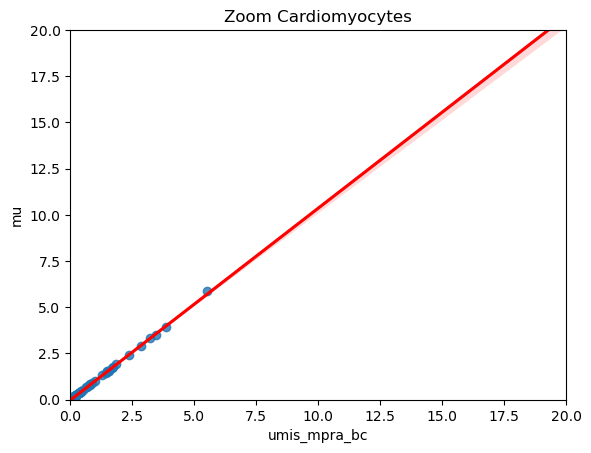

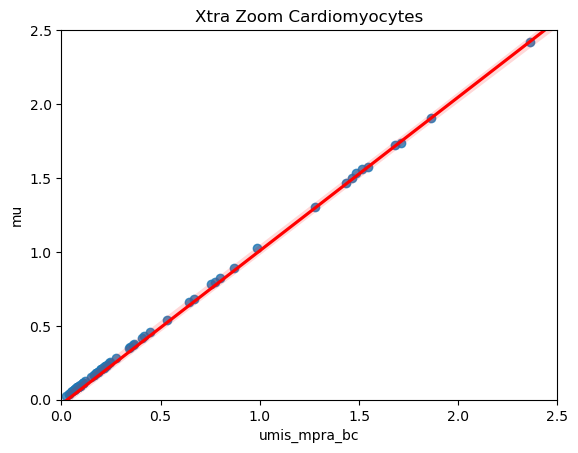

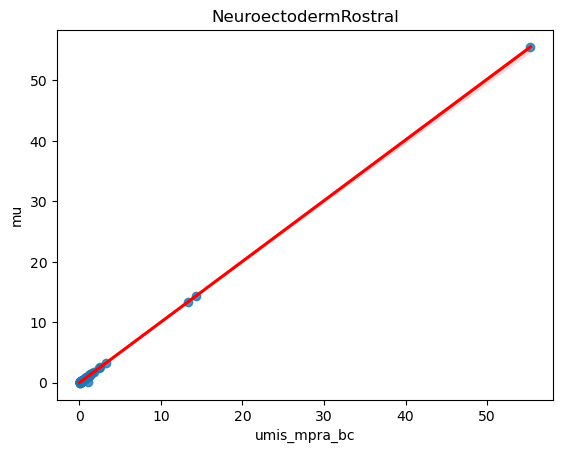

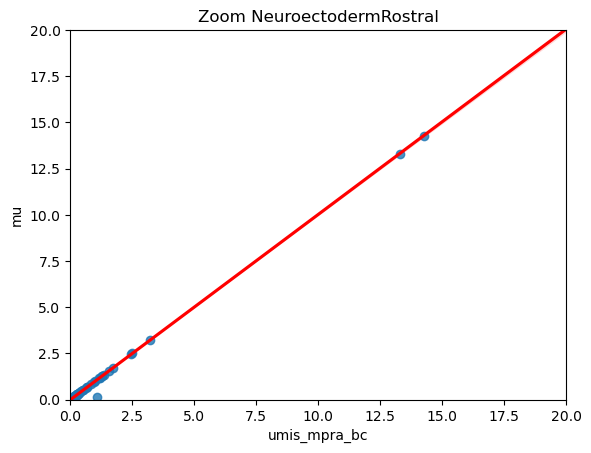

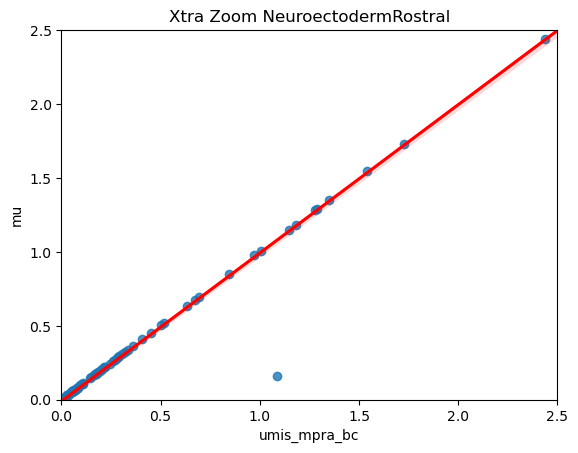

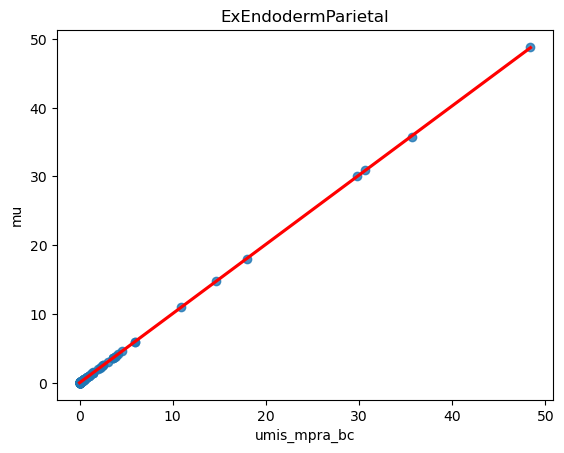

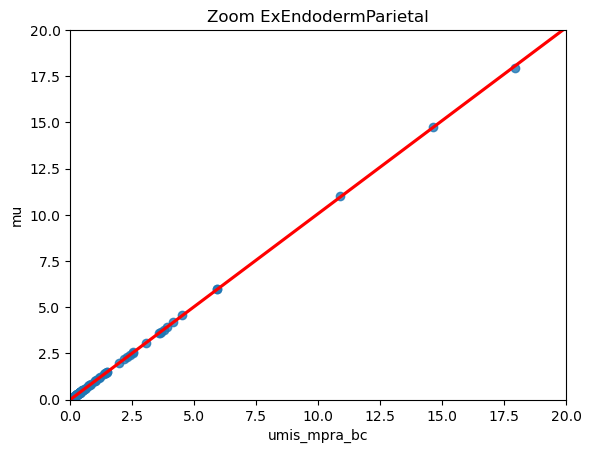

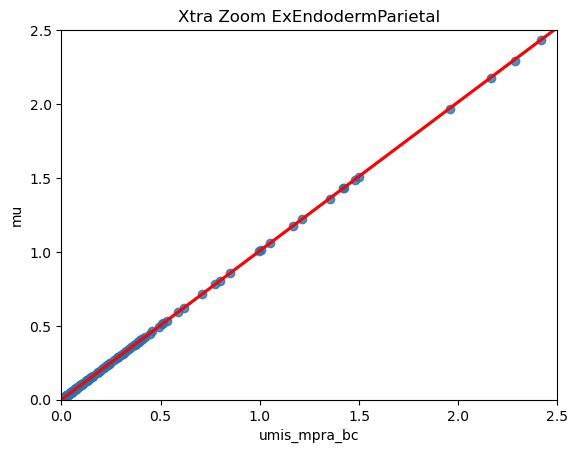

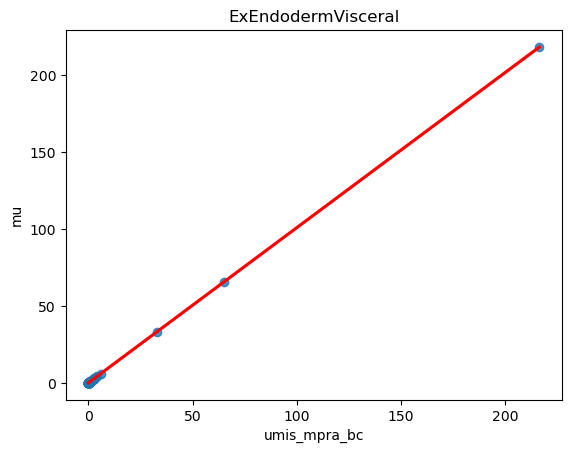

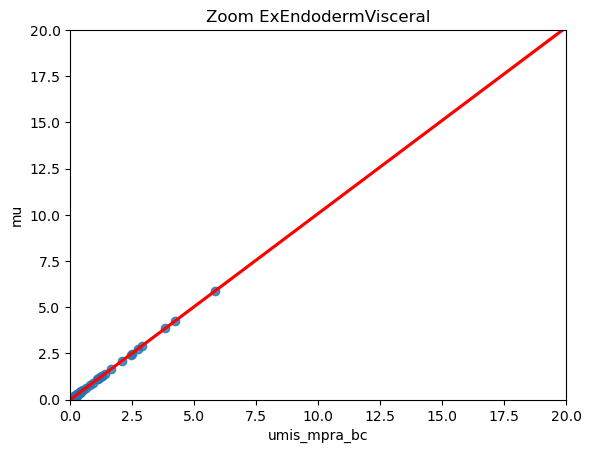

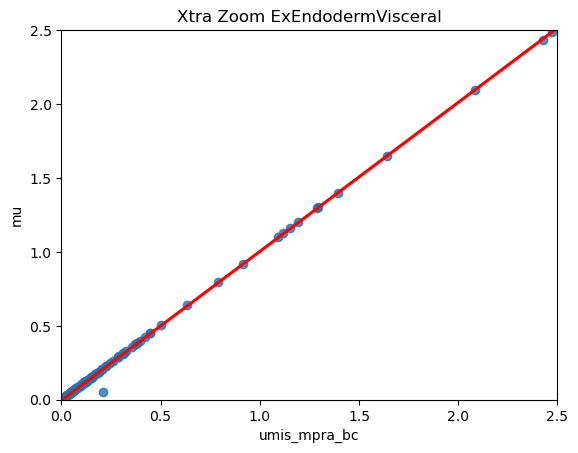

In [ ]:
for cell_type in QC:
    sns.regplot(x=QC[cell_type]["x"], y=QC[cell_type]["y"], scatter=True, line_kws={"color": "red"})
    plt.title(cell_type)
    plt.show()

    sns.regplot(x=QC[cell_type]["x"], y=QC[cell_type]["y"], scatter=True, line_kws={"color": "red"})
    plt.title(f"Zoom {cell_type}")
    plt.xlim(0, 20)   # Set x-axis limits
    plt.ylim(0, 20)   # Set y-axis limits
    plt.show()

    sns.regplot(x=QC[cell_type]["x"], y=QC[cell_type]["y"], scatter=True, line_kws={"color": "red"})
    plt.title(f"Xtra Zoom {cell_type}")
    plt.xlim(0, 2.5)   # Set x-axis limits
    plt.ylim(0, 2.5)   # Set y-axis limits
    plt.show()

    